# Top-down and bottom-up decompositions of the ATAG scenarios

The ATAG reproduction of S0, S1 and S2 is **top-down**: the efficiency, the operations and the offsets
of each scenario are curves read from its inputs. Its decomposition into the roadmap's pillars (fleet
renewal, next generation technology, operations, SAF, market-based measures) therefore needs
counterfactual runs: T0, the frozen technology, and T1, the renewal-only fleet.

This notebook runs the same three scenarios **bottom-up**, with the bottom-up fleet and the generic
operations and offsets modules, fitted to the top-down runs. The detailed decomposition of AeroMAPS
then applies without counterfactual runs: renewal and each new aircraft, each operational concept, each
energy pathway and each offsetting scheme are columns of the results. The levers are stacked in the
roadmap's order (`lever_order="atag"`): technology, then alternative aircraft, then operations and
load factor, then drop-in fuels, then offsets.

The notebook then compares the two on three counts: the decomposition itself, the pillar totals, and
the error of each bottom-up scenario with respect to its top-down original.

How the bottom-up scenarios are built: `build_scenarios.py` writes the operations and offsets from the
top-down inputs, and `calibrate_fleet.py` fits the fleet to the top-down energy per ASK, in this
folder. The scenario is packaged as `atag_3rd_edition_bottom_up`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import gemseo as gm
from aeromaps import create_process
from aeromaps.utils.decomposition import bottom_up_roadmap_pillars, pillar_totals
from aeromaps.utils.functions import custom_logger_config
from aeromaps.utils.results_view import load_results
from aeromaps.utils.scenario_tables import output_series
from aeromaps.utils.scenarios import prepare_scenario

warnings.filterwarnings("ignore")
custom_logger_config(gm.configure_logger())

HERE = Path.cwd()
PUBLICATION = HERE.parent
FULL = PUBLICATION / "3rd_edition_full" / "data_outputs"
LIGHT = PUBLICATION / "3rd_edition_light" / "data_outputs"
SCENARIOS = {"S0": LIGHT / "s0.json", "S1": FULL / "s1.json", "S2": FULL / "s2.json"}
FIRST_YEAR, ERROR_YEARS = 2000, (2030, 2040, 2050)

## Run the bottom-up scenarios and read the top-down ones

The top-down results are the committed ones of the third edition. T0 and T1 are the counterfactual
runs the top-down decomposition anchors on.

In [2]:
SCENARIO = prepare_scenario("atag_3rd_edition_bottom_up")

bottom_up = {}
for name in SCENARIOS:
    process = create_process(
        configuration_file=str(SCENARIO / "config_files" / f"config_{name.lower()}.yaml")
    )
    process.compute()
    bottom_up[name] = process

top_down = {name: load_results(path) for name, path in SCENARIOS.items()}
t0, t1 = load_results(FULL / "t0.json"), load_results(FULL / "t1.json")

    INFO - 16:55:52: Running MDA


    INFO - 16:55:56: Running MDA


    INFO - 16:56:00: Running MDA


## The two decompositions side by side

Top row: the ATAG decomposition of the top-down scenario, with T0 and T1 as anchors. Bottom row: the
detailed bottom-up decomposition in the same order. Where the top-down figure has one band for the
technology pillar, the bottom-up one splits it into fleet renewal and one band per new aircraft,
and the energy pillar is split per pathway.

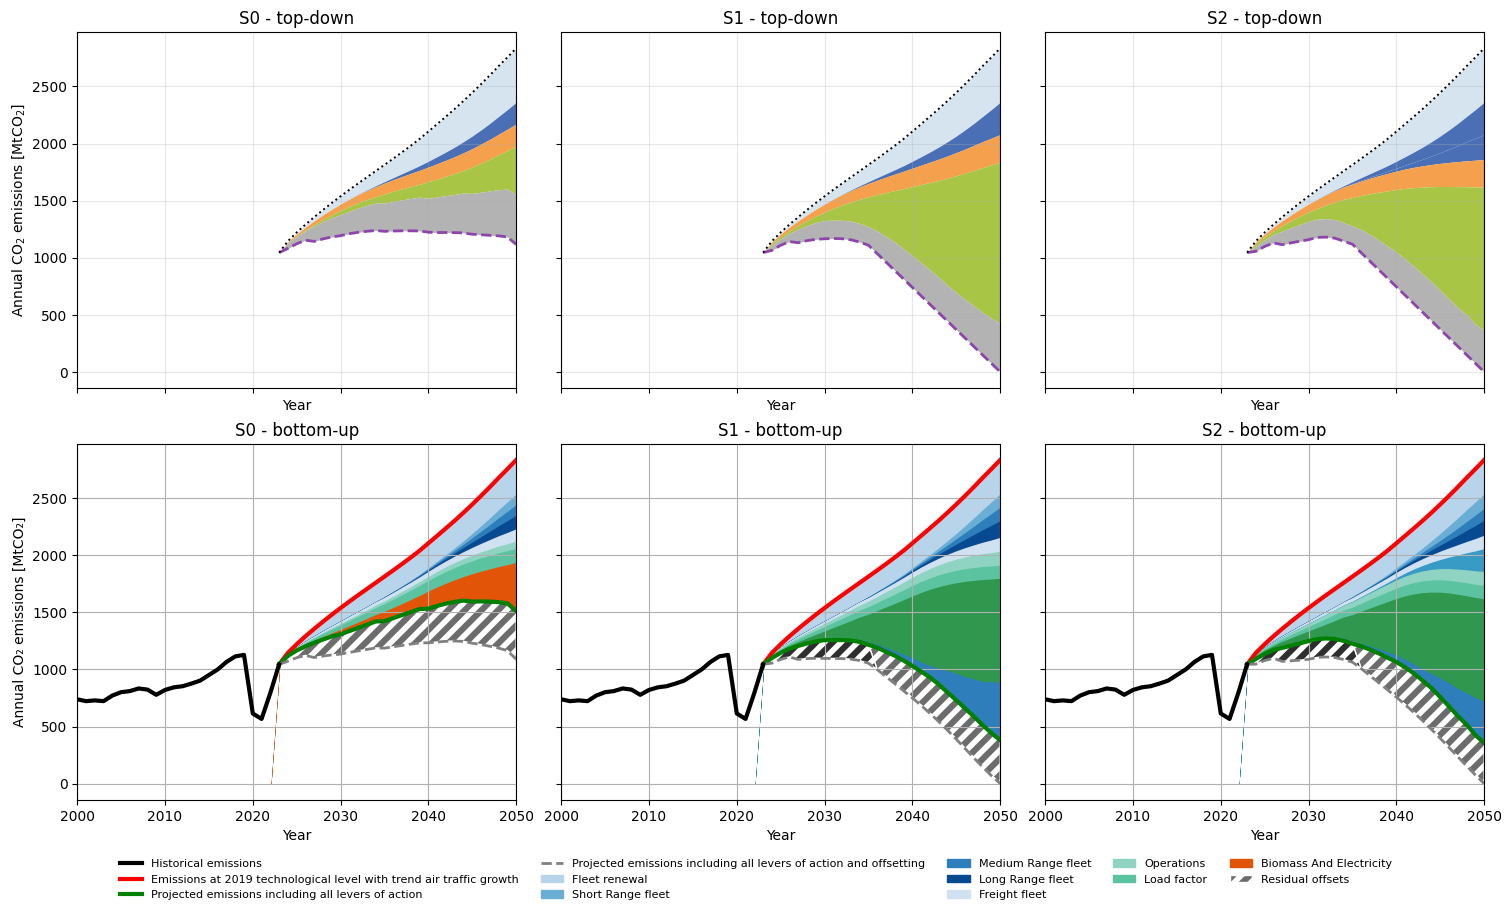

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True, layout="constrained")
for column, name in enumerate(SCENARIOS):
    top_down[name].plot(
        "mitigation_wedges", fig=fig, ax=axes[0, column], anchors=(t0, t1),
        legend=False, title=f"{name} - top-down",
    )
    bottom_up[name].plot(
        "air_transport_co2_emissions_detailed", fig=fig, ax=axes[1, column],
        legend=False, lever_order="atag", efficiency_granularity="category",
        energy_granularity="family",
    )
    axes[1, column].set_title(f"{name} - bottom-up")
for ax in axes[:, 1:].ravel():
    ax.set_ylabel("")
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=5, fontsize=8, frameon=False)
plt.show()

Without the grouping, each aircraft, each operational concept and each pathway is its own band.

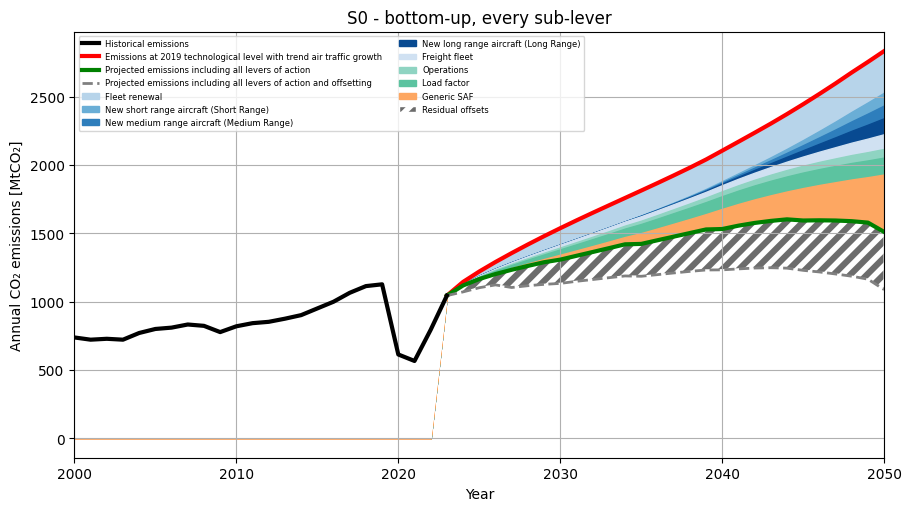

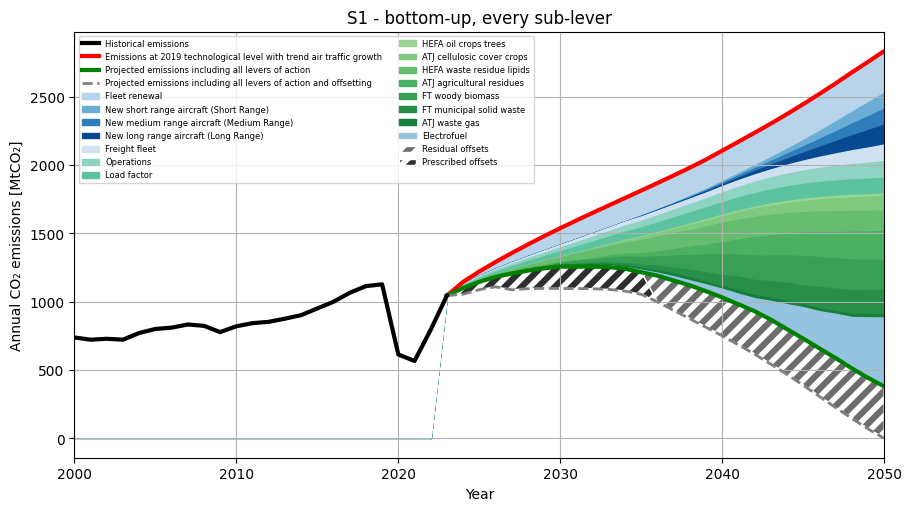

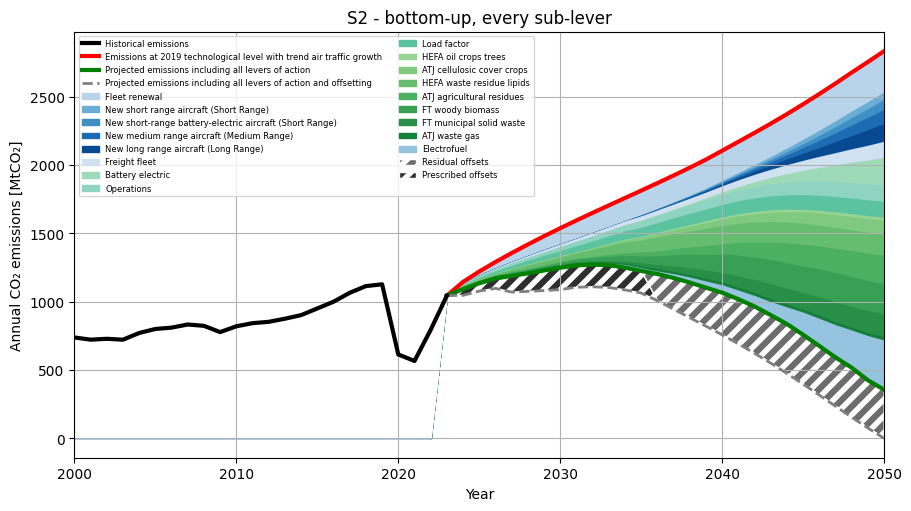

In [4]:
for name in SCENARIOS:
    bottom_up[name].plot("air_transport_co2_emissions_detailed", lever_order="atag")
    plt.gca().set_title(f"{name} - bottom-up, every sub-lever")

## Pillar totals

The top-down pillars come from `pillar_totals`, with the T0 and T1 anchors. The bottom-up ones come
from `bottom_up_roadmap_pillars`, which adds up the sub-wedges the roadmap groups in each pillar: renewal and
its continuous improvement, then the new aircraft, the freight fleet and the alternative aircraft;
operations with load factor; the drop-in pathways; the offsets. Both are in MtCO2 avoided in 2050.

In [5]:
LABELS = ["Fleet renewal", "Next gen. technology", "Operations", "SAF", "Market-based"]
KEYS = ["fleet_renewal", "next_generation", "operations", "saf", "market_based"]

rows = []
for name in SCENARIOS:
    pillars_td, gross_td = pillar_totals(top_down[name], anchors=(t0, t1), year=2050)
    pillars_bu = bottom_up_roadmap_pillars(bottom_up[name])
    gross_bu = float(pillars_bu.attrs["gross"].loc[2050])
    offset_td = float(output_series(top_down[name], "carbon_offset")[2050 - FIRST_YEAR])
    for label, key, td in zip(
        LABELS + ["Gross emissions"], KEYS + ["gross"], pillars_td + [offset_td, gross_td]
    ):
        bu = gross_bu if key == "gross" else float(pillars_bu.loc[2050, key])
        rows.append(
            {"scenario": name, "pillar": label, "top-down": td, "bottom-up": bu,
             "error": bu - td, "error %": 100 * (bu / td - 1) if abs(td) > 1 else np.nan}
        )
table = pd.DataFrame(rows).set_index(["scenario", "pillar"])
table.round(1)

top-down  bottom-up  error  error %
scenario pillar                                                   
S0       Fleet renewal            473.8      304.5 -169.3    -35.7
         Next gen. technology     189.7      411.7  222.1    117.1
         Operations               192.2      187.5   -4.7     -2.4
         SAF                      430.8      420.4  -10.5     -2.4
         Market-based             432.8      422.3  -10.5     -2.4
         Gross emissions        1,548.5    1,510.9  -37.6     -2.4
S1       Fleet renewal            473.8      304.5 -169.3    -35.7
         Next gen. technology     282.1      500.8  218.7     77.5
         Operations               242.6      236.9   -5.8     -2.4
         SAF                    1,412.9    1,412.9     -0       -0
         Market-based             423.6      379.9  -43.6    -10.3
         Gross emissions          423.6      379.9  -43.6    -10.3
S2       Fleet renewal            473.8      304.5 -169.3    -35.7
         Next gen. technology     500.2      677.8  177.6     35.5
         Operations               242.6      239.5   -3.1     -1.3
         SAF                    1,257.1    1,257.2    0.1        0
         Market-based             361.3        356   -5.3     -1.5
         Gross emissions          361.3        356   -5.3     -1.5

The top-down pillars stop at the physical levers; the market-based one is read from the carbon offset of each run, and the gross emissions are what is left once the physical levers have acted.

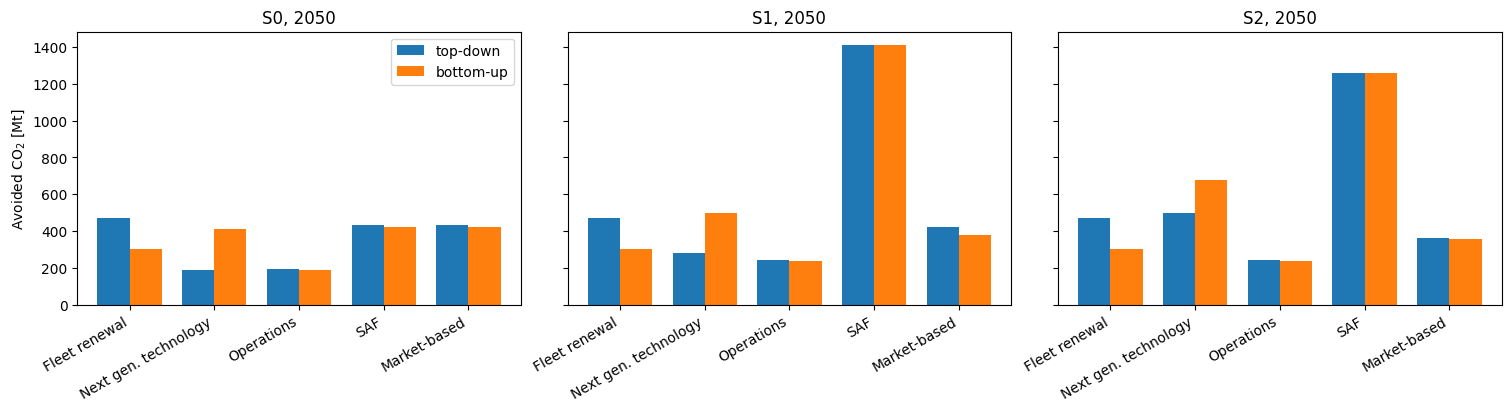

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, layout="constrained")
width = 0.38
for ax, name in zip(axes, SCENARIOS):
    sub = table.loc[name].drop("Gross emissions")
    x = np.arange(len(sub))
    ax.bar(x - width / 2, sub["top-down"], width, label="top-down")
    ax.bar(x + width / 2, sub["bottom-up"], width, label="bottom-up")
    ax.set_xticks(x, sub.index, rotation=30, ha="right")
    ax.set_title(f"{name}, 2050")
axes[0].set_ylabel("Avoided CO$_2$ [Mt]")
axes[0].legend()
plt.show()

## Error of the bottom-up scenarios with respect to the top-down ones

Relative error of the bottom-up variant over the top-down original, for the quantities the fit does
and does not constrain. The fleet is fitted to the energy per ASK, so the gross emissions inherit its
error; the offsets then follow the gross emissions through the share-of-residual rule.

In [7]:
QUANTITIES = {
    "Gross CO$_2$": "co2_emissions_including_energy",
    "Net CO$_2$": "co2_emissions",
    "Carbon offset": "carbon_offset",
    "Energy per ASK": "energy_per_ask_mean",
    "Energy per ASK, without operations": "energy_per_ask_mean_without_operations",
    "Energy consumption": "energy_consumption",
    "Load factor": "load_factor",
}


def series_of(view, name):
    if name == "co2_emissions":
        outputs = view.data["climate_outputs"] if isinstance(view.data, dict) else view.data["climate_outputs"]
        return np.asarray(outputs[name], dtype=float)
    return output_series(view, name)


def cumulative(values, first=2024, last=2050):
    return float(np.nansum(values[first - FIRST_YEAR : last - FIRST_YEAR + 1]))


rows = []
for name in SCENARIOS:
    for label, key in QUANTITIES.items():
        try:
            td, bu = series_of(top_down[name], key), series_of(bottom_up[name], key)
        except KeyError:
            continue
        row = {"scenario": name, "quantity": label}
        for year in ERROR_YEARS:
            i = year - FIRST_YEAR
            row[f"{year} [%]"] = 100 * (bu[i] / td[i] - 1) if abs(td[i]) > 1e-9 else np.nan
        c_td, c_bu = cumulative(td), cumulative(bu)
        row["2024-2050 [%]"] = 100 * (c_bu / c_td - 1) if abs(c_td) > 1e-9 else np.nan
        rows.append(row)
errors = pd.DataFrame(rows).set_index(["scenario", "quantity"])
errors.round(2)

2030 [%]  2040 [%]  2050 [%]  \
scenario quantity                                                           
S0       Gross CO$_2$                           -4.94      0.82     -2.43   
         Net CO$_2$                                 0         0         0   
         Carbon offset                          -4.94      0.82     -2.43   
         Energy per ASK                         -4.95      0.83     -2.43   
         Energy per ASK, without operations     -4.95      0.83     -2.43   
         Energy consumption                     -4.94      0.82     -2.43   
         Load factor                                0         0         0   
S1       Gross CO$_2$                           -5.22      1.45     -10.3   
         Net CO$_2$                                 0         0         0   
         Carbon offset                              0      1.45     -10.3   
         Energy per ASK                         -4.95      0.92     -2.37   
         Energy per ASK, without operations     -4.95      0.92     -2.37   
         Energy consumption                     -4.94      0.91     -2.38   
         Load factor                                0         0         0   
S2       Gross CO$_2$                           -5.25      1.67     -1.47   
         Net CO$_2$                                 0         0         0   
         Carbon offset                              0      1.67     -1.47   
         Energy per ASK                         -4.95      0.76     -1.29   
         Energy per ASK, without operations     -4.95      0.76     -1.29   
         Energy consumption                     -4.94      0.76     -1.28   
         Load factor                                0         0         0   

                                             2024-2050 [%]  
scenario quantity                                           
S0       Gross CO$_2$                                -1.42  
         Net CO$_2$                                      0  
         Carbon offset                               -0.98  
         Energy per ASK                              -1.69  
         Energy per ASK, without operations          -1.67  
         Energy consumption                          -1.34  
         Load factor                                     0  
S1       Gross CO$_2$                                   -2  
         Net CO$_2$                                      0  
         Carbon offset                                0.08  
         Energy per ASK                              -1.68  
         Energy per ASK, without operations          -1.65  
         Energy consumption                          -1.32  
         Load factor                                     0  
S2       Gross CO$_2$                                -1.38  
         Net CO$_2$                                      0  
         Carbon offset                                   2  
         Energy per ASK                              -1.67  
         Energy per ASK, without operations          -1.64  
         Energy consumption                          -1.29  
         Load factor                                     0

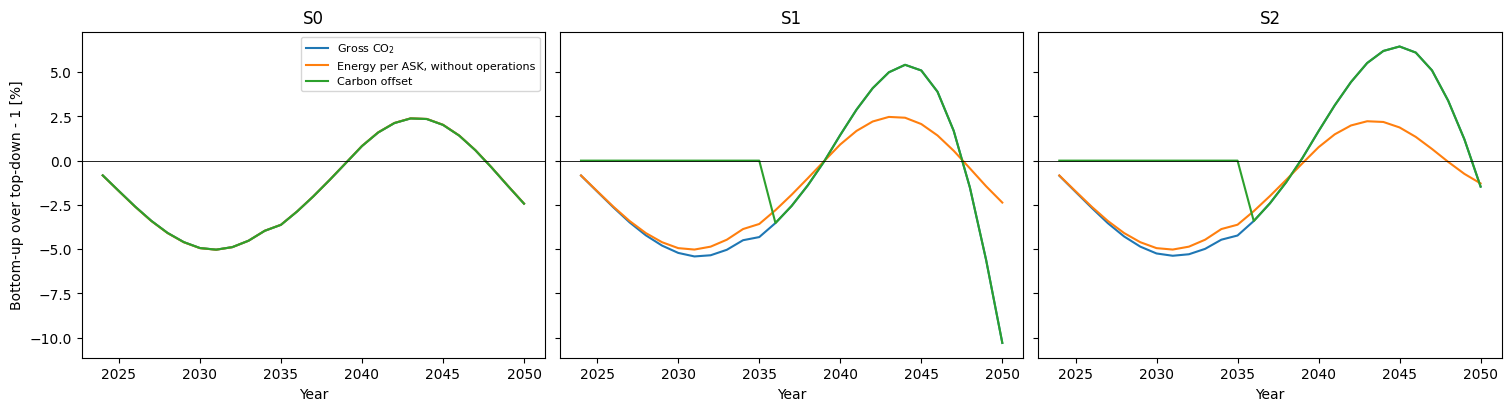

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, layout="constrained")
years = np.arange(2024, 2051)
for ax, name in zip(axes, SCENARIOS):
    for label in ("Gross CO$_2$", "Energy per ASK, without operations", "Carbon offset"):
        key = QUANTITIES[label]
        td, bu = series_of(top_down[name], key), series_of(bottom_up[name], key)
        i = years - FIRST_YEAR
        with np.errstate(divide="ignore", invalid="ignore"):
            ax.plot(years, 100 * (bu[i] / td[i] - 1), label=label)
    ax.axhline(0, color="k", linewidth=0.6)
    ax.set_title(name)
    ax.set_xlabel("Year")
axes[0].set_ylabel("Bottom-up over top-down - 1 [%]")
axes[0].legend(fontsize=8)
plt.show()

## Pillars over time

The same pillars year by year. The gap between the two curves of a pillar is the part of the error that
the structure of the bottom-up fleet cannot absorb: a fleet renews in steps, where the top-down curve is
smooth.

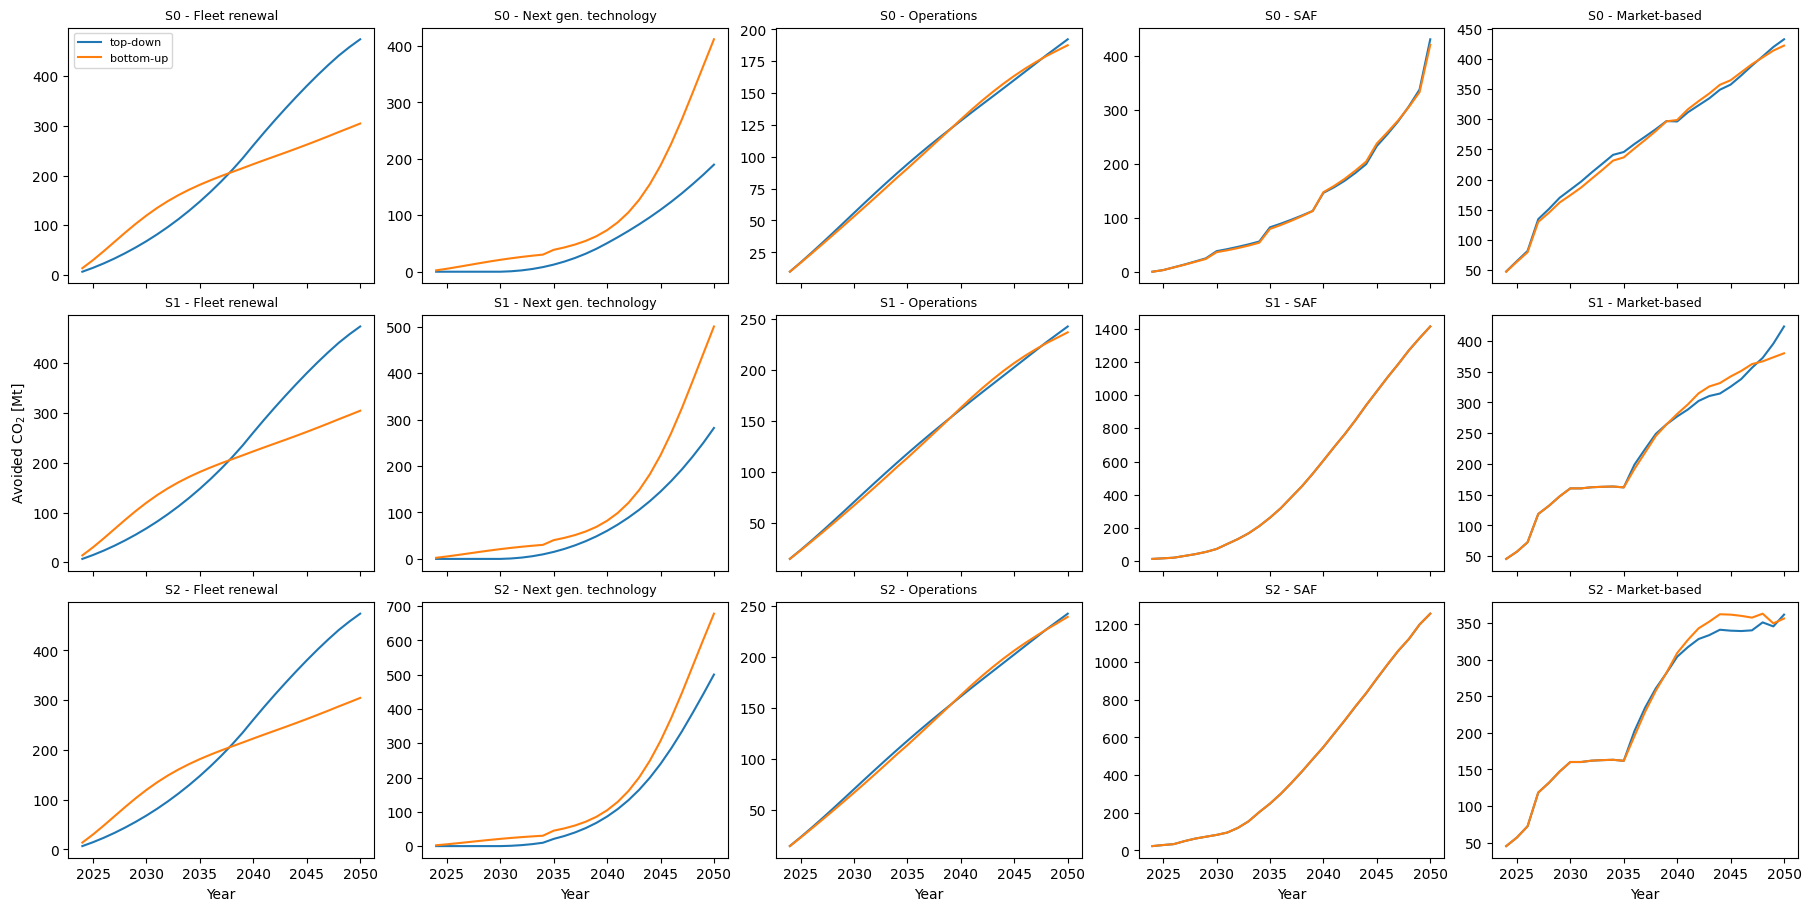

In [9]:
fig, axes = plt.subplots(len(SCENARIOS), 5, figsize=(18, 9), sharex=True, layout="constrained")
for row, name in enumerate(SCENARIOS):
    bu = bottom_up_roadmap_pillars(bottom_up[name]).loc[2024:2050]
    from aeromaps.utils.decomposition import mitigation_wedges

    years_td, b = mitigation_wedges(top_down[name], anchors=(t0, t1))
    mask = years_td >= 2024
    td = {
        "fleet_renewal": b[0] - b[1],
        "next_generation": (b[1] - b[2]) + (b[2] - b[3]),
        "operations": b[3] - b[4],
        "saf": b[4] - b[5],
        "market_based": b[5] - b[6],
    }
    for column, (key, label) in enumerate(zip(KEYS, LABELS)):
        ax = axes[row, column]
        ax.plot(years_td[mask], td[key][mask], label="top-down")
        ax.plot(bu.index, bu[key], label="bottom-up")
        ax.set_title(f"{name} - {label}", fontsize=9)
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Year")
axes[1, 0].set_ylabel("Avoided CO$_2$ [Mt]")
plt.show()

## Reading the differences

- **Fleet renewal against next generation technology.** This is where the two decompositions differ most (renewal 304 against 474 Mt in 2050 in all three scenarios). In the top-down decomposition, renewal is whatever the T1 run achieves without any new aircraft. In the bottom-up one, a new aircraft that replaces an old reference aircraft is credited with the whole gain, including the part a renewal with the recent reference would have given, so renewal is smaller and the new aircraft larger. Their sum is much closer: 805 against 756 Mt for S1 (+6.5 %).
- **Fit error.** The new aircraft's gain is fitted on S1 only (against T3). S0 scales it down by the ratio of the reductions T2 and T3 achieve, and S2 keeps S1's gain, so S0 and S2 are estimates, not fits. Energy per ASK is 2 to 5 % off the top-down run, 5 % low in 2030 (the bottom-up fleet renews in a step from 2035) and 1 to 2 % low in 2050.
- **Operations and SAF.** The operations gain is the same curve in both, and the SAF pillar is identical in S1 and S2 to within 0.1 Mt. Differences in the offsets follow the gross emissions they apply to, and reach 10 % in S1 in 2050 because the residual share is almost 100 %: a 2 % error on the gross emissions is a larger share of what is left.
- **Alternative aircraft.** S2's electric aircraft are in the technology pillar in both decompositions, as the roadmap counts them.


In [10]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals(), force_cleanup=False)

    INFO - 16:56:07: 🧹 clean_notebooks_on_tests called


    INFO - 16:56:07: ⏭ Skipping cleanup during notebook run
